In [1]:
import numpy as np

def compute_mae(var, var_hat):
    return np.sum(np.abs(var - var_hat)) / var.shape[0]

def compute_rmse(var, var_hat):
    return np.sqrt(np.sum((var - var_hat) ** 2) / var.shape[0])

In [2]:
import numpy as np

def ar(y, d):
    t = y.shape[0]
    vec = y[d:]
    mat = np.vstack([y[d-i-1 : t-i-1] for i in range(d)]).T   # (T-d) x d
    return np.linalg.pinv(mat) @ vec

def time_series_pred_multi(data, coef, horizon, step):
    t = data.shape[0]
    d = coef.shape[0]

    origins = np.arange(t - horizon, t) - step + 1             # (horizon,)
    assert origins.min() - d >= 0, "history too short"

    win = np.stack([data[o - d : o] for o in origins])         # horizon x d

    for _ in range(step):
        pred = win[:, ::-1] @ coef                             # (horizon,)
        win = np.hstack([win[:, 1:], pred[:, None]])

    return pred

In [3]:
import pandas as pd

df = pd.read_csv('AI-small-data.csv', index_col = 0)

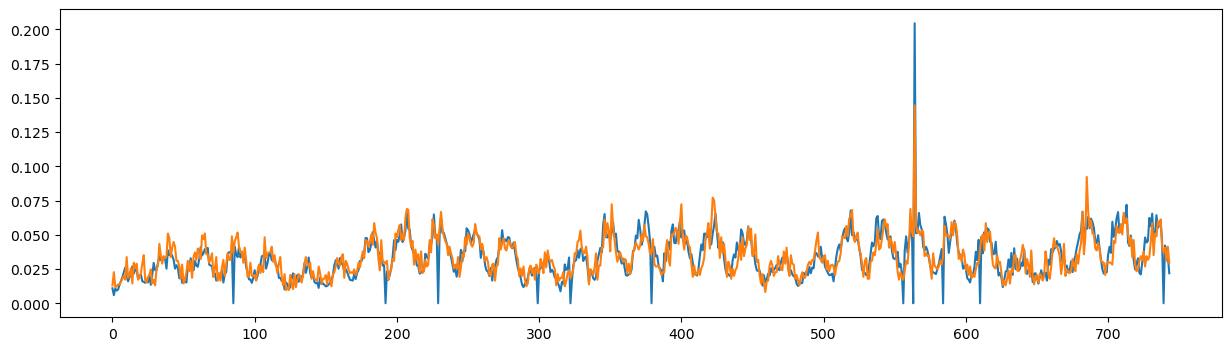

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
# x = df.loc['Artificial_intelligence'].values[: 24 * 31]
# plt.plot(x / np.linalg.norm(x, 2))
x = df.loc['Machine_learning'].values[: 24 * 31]
plt.plot(x / np.linalg.norm(x, 2))
x = df.loc['Deep_learning'].values[: 24 * 31]
plt.plot(x / np.linalg.norm(x, 2))
plt.show()

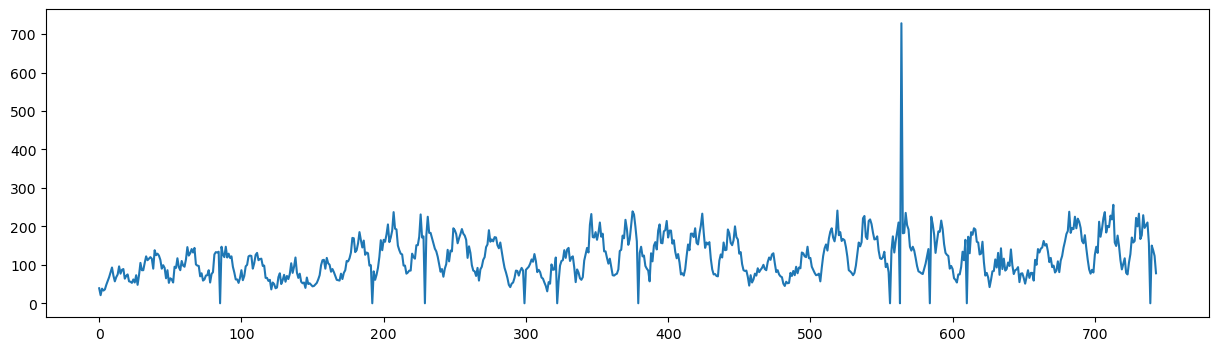

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
x = df.loc['Machine_learning'].values[: 24 * 31]
plt.plot(x)
# x = df.loc['Deep_learning'].values[: 24 * 31]
# plt.plot(x)
plt.show()

In [6]:
x = df.loc['Machine_learning'].values[: 24 * 31]

d = 168
coef = ar(x[: 24 * (31 - 14)], d)
horizon = 168
step = 12

est = time_series_pred_multi(x, coef, horizon, step)

print('MAE: {:.6}'.format(compute_mae(x[-horizon:].reshape(-1), est.reshape(-1))))
print('RMSE: {:.6}'.format(compute_rmse(x[-horizon:].reshape(-1), est.reshape(-1))))

MAE: 64.6782
RMSE: 81.7272


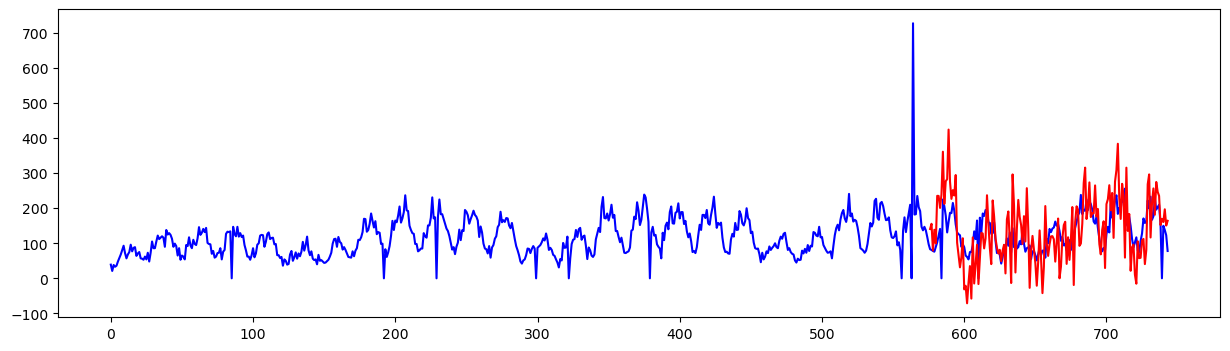

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(x, 'b-')
plt.plot(np.arange(24 * 24, 31 * 24), est, 'r-')
plt.show()

In [8]:
mat = np.zeros((horizon, 2))
mat[:, 0] = np.arange(1, 169)
mat[:, 1] = est
np.savetxt('ml_result.txt', mat)

In [9]:
x = df.loc['Bayesian_network'].values[: 24 * 31]

d = 168
coef = ar(x[: 24 * (31 - 14)], d)
horizon = 168
step = 12

est = time_series_pred_multi(x, coef, horizon, step)

print('MAE: {:.6}'.format(compute_mae(x[-horizon:].reshape(-1), est.reshape(-1))))
print('RMSE: {:.6}'.format(compute_rmse(x[-horizon:].reshape(-1), est.reshape(-1))))

MAE: 6.33201
RMSE: 8.2386


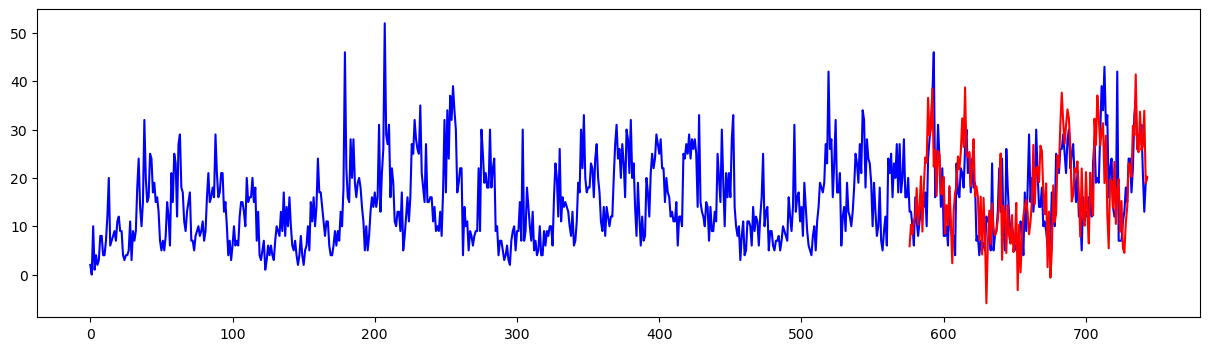

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(x, 'b-')
plt.plot(np.arange(24 * 24, 31 * 24), est, 'r-')
plt.show()

In [11]:
mat = np.zeros((horizon, 2))
mat[:, 0] = np.arange(1, 169)
mat[:, 1] = est
np.savetxt('bn_result.txt', mat)

In [12]:
import numpy as np

x = df.loc['Machine_learning'].values[: 24 * 31]
num = 100
for degree in [1, 3, 7, 11]:
    mae = 0
    rmse = 0
    for i in range(num):
        np.random.seed(i)
        rng = np.random.default_rng()
        noise = rng.standard_t(degree, size=(24 * (31 - 7)))
        
        d = 168
        coef = ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d)
        horizon = 168
        step = 12
        est = time_series_pred_multi(x, coef, horizon, step)
        
        mae += compute_mae((x[- horizon :]).reshape(-1), est.reshape(-1))
        rmse += compute_rmse((x[- horizon :]).reshape(-1), est.reshape(-1))
    print('MAE: {:.6}'.format(mae / num))
    print('RMSE: {:.6}'.format(rmse / num))
    print()

MAE: 71.4153
RMSE: 94.0494

MAE: 64.7224
RMSE: 81.8228

MAE: 64.6392
RMSE: 81.7497

MAE: 64.8087
RMSE: 82.0005



In [13]:
import numpy as np

x = df.loc['Bayesian_network'].values[: 24 * 31]
num = 100
for degree in [1, 3, 7, 11]:
    mae = 0
    rmse = 0
    for i in range(num):
        np.random.seed(i)
        rng = np.random.default_rng()
        noise = rng.standard_t(degree, size=(24 * (31 - 7)))
        
        d = 168
        coef = ar(x[: 24 * (31 - 14)] + noise[: 24 * (31 - 14)], d)
        horizon = 168
        step = 12
        est = time_series_pred_multi(x, coef, horizon, step)
        
        mae += compute_mae((x[- horizon :]).reshape(-1), est.reshape(-1))
        rmse += compute_rmse((x[- horizon :]).reshape(-1), est.reshape(-1))
    print('MAE: {:.6}'.format(mae / num))
    print('RMSE: {:.6}'.format(rmse / num))
    print()

MAE: 19.4765
RMSE: 24.0452

MAE: 6.38962
RMSE: 8.28296

MAE: 6.36394
RMSE: 8.28072

MAE: 6.35486
RMSE: 8.29644

